In [2]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50}, method="L-BFGS-B")
    plt.plot(res["loss_history"])
    plt.show()

def get_kernel():
    return gpf.kernels.Matern32()

2026-08-13 11:08:23.950491: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-13 11:08:23.956080: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-13 11:08:24.038035: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-13 11:08:24.043913: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-13 11:08:25.719220: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

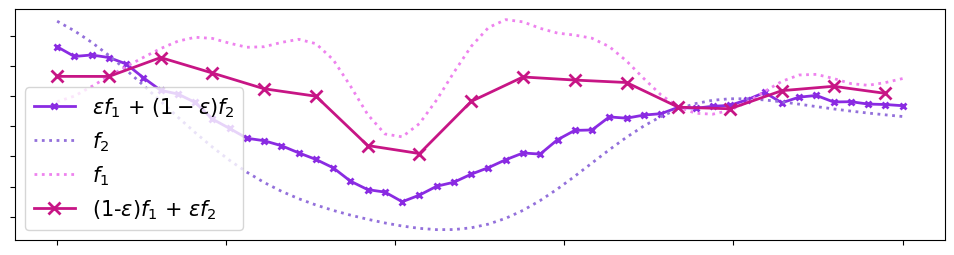

In [89]:
Xs = np.linspace(0, 50, 50).reshape(-1, 1)
Xt = np.linspace(0, 50, 50).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10, variance=5)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))

prop = 0.7
ys = (prop * f1 + (1-prop) * f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = ((1-prop)* f1 + prop * f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 3 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 3 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.figure(figsize=(12, 3))
plt.tick_params(
    axis='both',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    labelleft=False,
    labelbottom=False
) # labels along the bottom edge are off
plt.plot(Xs, ys, color="blueviolet", marker="x", ms=5, lw=2, mew=2, label="$\epsilon$$f_1$ + $(1-\epsilon)$$f_2$")
plt.plot(Xs, f1, color="mediumpurple", linestyle=":", lw=2, label="$f_2$")
plt.plot(Xs, f2, color="violet", linestyle=":", lw=2, label="$f_1$")
plt.plot(Xt, yt, color="mediumvioletred", marker="x", ms=8, mew=2, lw=2,label="(1-$\epsilon$)$f_1$ + $\epsilon$$f_2$")
plt.legend(fontsize=15)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt, np.ones_like(Xt)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt, np.ones_like(yt)))))


In [ ]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel() 

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)


ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((25,1 )), np.zeros((25, 1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg 
m = SparseCMOGP((X, y), jitter=0.00001, inducing_variable=ivs, kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value        │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0          │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0          │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────┤
│ SparseCMOGP

In [ ]:
w = m.kernel.kernels[1].W.numpy()
b = w @ w.T
print(b / np.max(b))

[[0.8978918  0.94757153]
 [0.94757153 1.        ]]


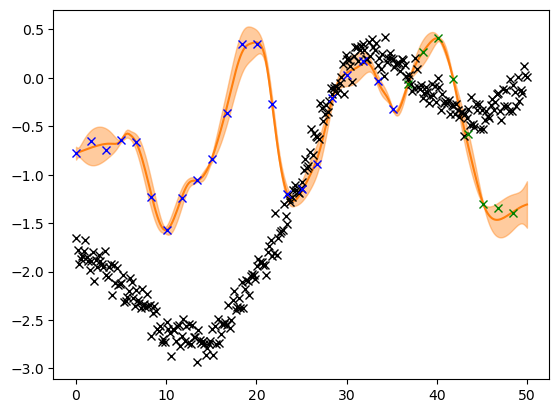

0.003654678296431261

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xs.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xt_test, np.ones_like(Xt_test)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(Xs, ys, "kx")
plt.plot(Xt_train, yt_train, "bx")
plt.plot(Xt_test, yt_test, "gx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

cmogp_mse = mean_squared_error(yt_test, fmean_tst)
cmogp_mse

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
from robust_svgp import LMCInducingPointsBase
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel()

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = TransferLikelihood(
    source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()
)

ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((25,1 )), np.zeros((25, 1))))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
# now build the GP model as normal

m = gpf.models.SVGP(kernel=kern, inducing_variable=LMCInducingPointsBase(ivs), num_data=len(X), likelihood=lik)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)), 
    m.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(m)

2026-08-10 10:05:35.791208: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-08-10 10:05:35.832272: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 0.9486505881782064                                   │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()         

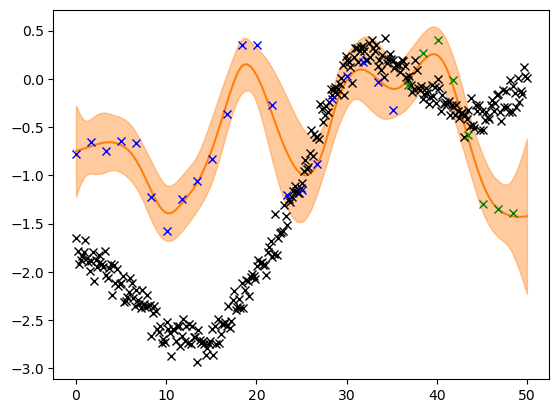

0.010731493801354538

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xs.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xt_test, np.ones_like(Xt_test)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(Xs, ys, "kx")
plt.plot(Xt_train, yt_train, "bx")
plt.plot(Xt_test, yt_test, "gx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

svgp_mse = mean_squared_error(yt_test, fmean_tst)
svgp_mse

In [ ]:
w = m.kernel.kernels[1].W.numpy()
b = w @ w.T
print(b / np.max(b))

[[0.01079487 0.10389836]
 [0.10389836 1.        ]]
